In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
data = load_diabetes()

X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target shape:", y.shape)

print("\nFeature names:")
print(data.feature_names)

Number of samples: 442
Number of features: 10
Target shape: (442,)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [5]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),

    "Polynomial Regression (Degree 2)":
        Pipeline([
            ("poly", PolynomialFeatures(
                degree=2,
                include_bias=False
            )),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])
}

print("Models defined successfully.")

for name in models:
    print("-", name)

Models defined successfully.
- Linear Regression
- Ridge Regression
- Polynomial Regression (Degree 2)


In [6]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,42.794095,2900.193628,53.853446,0.452603
1,Ridge Regression,42.811999,2892.014566,53.777454,0.454147
2,Polynomial Regression (Degree 2),43.581693,3096.028307,55.641965,0.415640


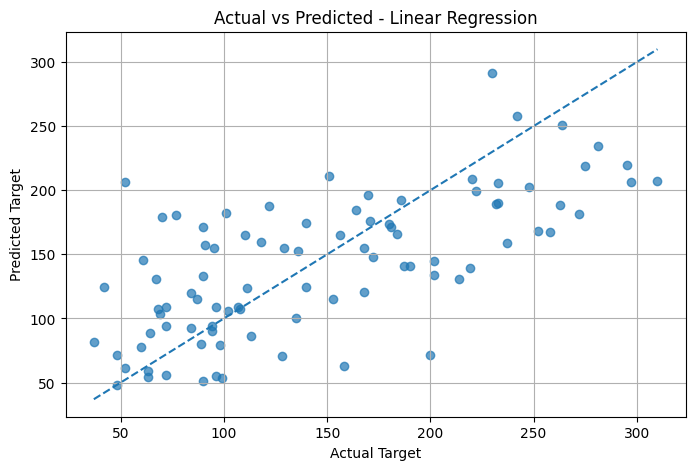

In [7]:
linear_model = models["Linear Regression"]

linear_predictions = linear_model.predict(X_test)

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted - Linear Regression")

plt.grid(True)
plt.show()

In [8]:
class GradientDescentLinearRegression:

    def __init__(
        self,
        learning_rate=0.03,
        epochs=5000
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            # Prediction
            predictions = (
                X @ self.weights
                + self.bias
            )

            # Error
            error = predictions - y

            # Gradients
            dw = (
                2 / n_samples
            ) * (X.T @ error)

            db = (
                2 / n_samples
            ) * np.sum(error)

            # Update parameters
            self.weights -= (
                self.learning_rate * dw
            )

            self.bias -= (
                self.learning_rate * db
            )

            # Calculate MSE
            loss = np.mean(error ** 2)

            self.loss_history.append(loss)

        return self

    def predict(self, X):

        return (
            X @ self.weights
            + self.bias
        )


print("Gradient Descent class created successfully.")

Gradient Descent class created successfully.


In [9]:
scaler_gd = StandardScaler()

X_train_scaled = scaler_gd.fit_transform(X_train)
X_test_scaled = scaler_gd.transform(X_test)

print("Feature standardization completed.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature standardization completed.
Training data shape: (353, 10)
Testing data shape: (89, 10)


In [10]:
gd_model = GradientDescentLinearRegression(
    learning_rate=0.03,
    epochs=5000
)

gd_model.fit(
    X_train_scaled,
    y_train
)

print("Gradient Descent training completed.")
print("Learning rate:", gd_model.learning_rate)
print("Number of epochs:", gd_model.epochs)

Gradient Descent training completed.
Learning rate: 0.03
Number of epochs: 5000


In [11]:
gd_predictions = gd_model.predict(
    X_test_scaled
)

print("Predictions generated successfully.")
print("Number of predictions:", len(gd_predictions))

Predictions generated successfully.
Number of predictions: 89


In [12]:
gd_mae = mean_absolute_error(
    y_test,
    gd_predictions
)

gd_mse = mean_squared_error(
    y_test,
    gd_predictions
)

gd_rmse = np.sqrt(gd_mse)

gd_r2 = r2_score(
    y_test,
    gd_predictions
)

print("Gradient Descent Results")
print("------------------------")

print("MAE  :", gd_mae)
print("MSE  :", gd_mse)
print("RMSE :", gd_rmse)
print("R2   :", gd_r2)

Gradient Descent Results
------------------------
MAE  : 42.79930200297788
MSE  : 2898.1208408378143
RMSE : 53.83419768918094
R2   : 0.45299399141422436


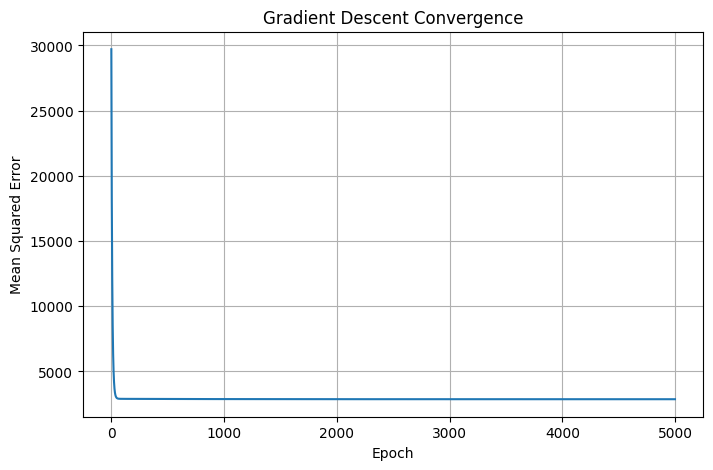

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    gd_model.loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.title(
    "Gradient Descent Convergence"
)

plt.grid(True)

plt.show()

In [14]:
initial_mse = gd_model.loss_history[0]
final_mse = gd_model.loss_history[-1]

print("Initial MSE:", initial_mse)
print("Final MSE:", final_mse)

print("\nObservation:")

if final_mse < initial_mse:
    print("MSE decreased during Gradient Descent optimization.")
else:
    print("MSE did not decrease during optimization.")

Initial MSE: 29711.32294617564
Final MSE: 2868.673304513274

Observation:
MSE decreased during Gradient Descent optimization.


In [15]:
gd_results = pd.DataFrame([
    {
        "Model":
            "Gradient Descent Linear Regression",

        "MAE":
            gd_mae,

        "MSE":
            gd_mse,

        "RMSE":
            gd_rmse,

        "R2 Score":
            gd_r2
    }
])

final_results = pd.concat(
    [
        results_df,
        gd_results
    ],
    ignore_index=True
)

final_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,42.794095,2900.193628,53.853446,0.452603
1,Ridge Regression,42.811999,2892.014566,53.777454,0.454147
2,Polynomial Regression (Degree 2),43.581693,3096.028307,55.641965,0.415640
3,Gradient Descent Linear Regression,42.799302,2898.120841,53.834198,0.452994
